# Getting started: `Structure`, `Calculation`, and the core `get_*()` workflow

elkpy wraps [Elk](https://elk.sourceforge.io/), an all-electron FP-LAPW DFT code, in a
small `pyqula`-style object model: a `Structure` (lattice + species) builds a
`Calculation` (a run directory + the ground-state-defining parameters), and
`Calculation.get_*()` methods run a real Elk subprocess and return parsed NumPy
arrays.

This notebook covers the core v0 slice: `get_energy()`, `get_bands()`, `get_dos()`,
on bulk silicon. See `docs/design.md` for the full architecture.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

from elkpy.structure import Structure

## Building a `Structure`

Lattice vectors (`avec`, in Bohr) and species positions (fractional/lattice
coordinates). Bulk Si, diamond structure, conventional two-atom primitive cell.

In [2]:
SI_AVEC = [(5.13, 5.13, 0.00), (5.13, 0.00, 5.13), (0.00, 5.13, 5.13)]
SI_SPECIES = {"Si": [(0.0, 0.0, 0.0), (0.25, 0.25, 0.25)]}

structure = Structure(SI_AVEC, SI_SPECIES)
structure.species

OrderedDict([('Si',
              [((0.0, 0.0, 0.0), (0.0, 0.0, 0.0)),
               ((0.25, 0.25, 0.25), (0.0, 0.0, 0.0))])])

An ASE `Atoms` object works too, via `Structure.from_ase()` (optional `ase`
dependency) -- convenient for pulling a structure from ASE's own builders
(`ase.build.bulk`, CIF readers, etc). Below, ASE's conventional diamond-Si lattice
constant (5.431 Angstrom) and the hand-written `SI_AVEC` above (5.13 Bohr) describe
the same physical cell -- converting confirms it, rather than just asserting it --
so we'll use the explicit one for the rest of this notebook.

In [3]:
from ase.build import bulk

from elkpy.structure import BOHR_PER_ANGSTROM

ase_structure = Structure.from_ase(bulk("Si", "diamond", a=5.431))
print("SI_AVEC[0] (Bohr):                 ", SI_AVEC[0])
print("ase_structure.avec[0] (Bohr):       ", tuple(round(x, 4) for x in ase_structure.avec[0]))
print("bulk('Si').cell[0] (Angstrom->Bohr):", tuple(round(x * BOHR_PER_ANGSTROM, 4) for x in bulk("Si", "diamond", a=5.431).cell[0]))
ase_structure.species

SI_AVEC[0] (Bohr):                  (5.13, 5.13, 0.0)
ase_structure.avec[0] (Bohr):        (np.float64(0.0), np.float64(5.1316), np.float64(5.1316))
bulk('Si').cell[0] (Angstrom->Bohr): (np.float64(0.0), np.float64(5.1316), np.float64(5.1316))


OrderedDict([('Si',
              [((np.float64(0.0), np.float64(0.0), np.float64(0.0)),
                (0.0, 0.0, 0.0)),
               ((np.float64(0.25),
                 np.float64(0.25),
                 np.float64(0.24999999999999997)),
                (0.0, 0.0, 0.0))])])

## `get_energy()`

`Structure.get_calculation()` builds a `Calculation` bound to a run directory. The
first `get_*()` call runs Elk's ground-state task (task 0) and caches it
(`.elkpy_manifest.json` + `STATE.OUT`) -- a second call with the same
basis-defining parameters is a cache hit, not a re-run.

In [4]:
calc = structure.get_calculation(
    "_scratch/si", xc="PW", ngridk=(2, 2, 2), vkloff=(0.25, 0.5, 0.625)
)

energy = calc.get_energy()
print(f"total energy: {energy:.6f} Hartree")
print(f"converged: {calc.converged}")

total energy: -578.103988 Hartree
converged: True


## `get_bands()`

Band structure along a path (Elk task 20, resumed from the cached ground state, in
its own wiped-clean subdirectory -- see `Calculation._run_resumed`'s docstring for
why). Pass either explicit `vertices` (fractional reciprocal coordinates) or a
symbolic `kpath` string resolved via ASE's Bravais-lattice-aware special points.

energies shape (nbands, npoints): (13, 200)


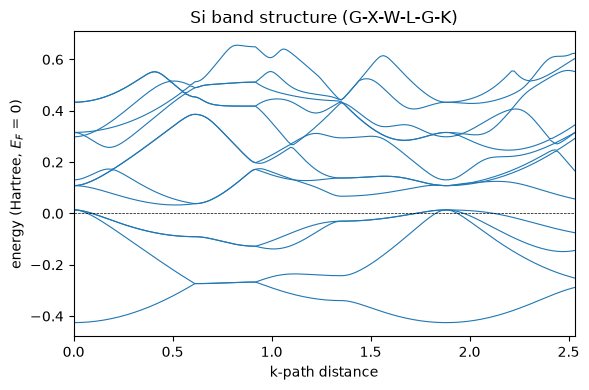

In [5]:
distances, energies = calc.get_bands(kpath="GXWLGK", npoints=200)
print("energies shape (nbands, npoints):", energies.shape)

fig, ax = plt.subplots(figsize=(6, 4))
for band in energies:
    ax.plot(distances, band, color="tab:blue", lw=0.8)
ax.axhline(0.0, color="k", lw=0.5, ls="--")
ax.set_xlim(distances[0], distances[-1])
ax.set_xlabel("k-path distance")
ax.set_ylabel("energy (Hartree, $E_F$ = 0)")
ax.set_title("Si band structure (G-X-W-L-G-K)")
fig.tight_layout()

## `get_dos()`

Total density of states (Elk task 10). `ngridk` can optionally be overridden just
for this call -- a denser sampling mesh than the ground state used, without
mutating the cached ground state (see `docs/design.md` #4).

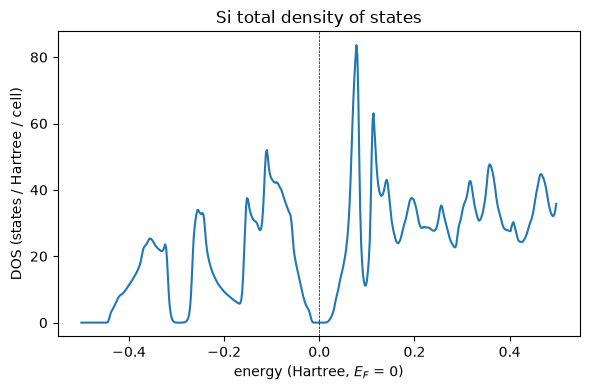

In [6]:
energies_dos, dos = calc.get_dos(ngridk=(6, 6, 6))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(energies_dos, dos)
ax.axvline(0.0, color="k", lw=0.5, ls="--")
ax.set_xlabel("energy (Hartree, $E_F$ = 0)")
ax.set_ylabel("DOS (states / Hartree / cell)")
ax.set_title("Si total density of states")
fig.tight_layout()

## Next

- `02_relaxation_forces_and_properties.ipynb` -- forces, structural relaxation,
  effective mass, charge density, and the `run_tasks()` escape hatch.
- `03_phonon_dispersion_and_dos.ipynb` -- DFPT phonons.
- `04_per_species_soc_scaling.ipynb`, `05_berry_curvature.ipynb`,
  `06_eigenstate_session.ipynb` -- the elkpy-specific Fortran extensions (not
  upstream Elk capability).